In [336]:
import ast
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt

In [337]:
df = pd.read_csv("imdb.csv")

In [338]:
df

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,genres,castNumber,companiesNumber,averageRating,regions,externalLinks,writerCredits,directorsCredits,soundMixes,quotesTotal
0,Carmencita,"(5, 6]",1894,\N,1,0,2089,1,10,2,...,"Documentary,Short",1,3,5.7,"['\\N', 'DE', 'US', 'HU', 'GR', 'RU', 'UA', 'JP']",9,0,1,['silent'],0
1,Un bon bock,"(5, 6]",1892,\N,12,0,183,1,10,2,...,"Animation,Short",0,0,5.4,"['\\N', 'HU', 'DE', 'FR', 'RO', 'RU', 'JP']",3,0,1,['silent'],0
2,Chinese Opium Den,"(4, 5]",1894,\N,1,0,195,1,10,1,...,Short,0,1,5.0,"['\\N', 'US', 'DE', 'PT', 'HU', 'RU']",4,0,1,['silent'],0
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,\N,1,1,2237,1,10,3,...,"Documentary,Short",1,6,5.4,"['\\N', 'UA', 'JP', 'HU', 'US', 'DE', 'RU']",6,0,1,['silent'],0
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,\N,1,0,13115,1,10,12,...,"Documentary,Short",6,5,7.4,"['\\N', 'HU', 'DE', 'TR', 'FI', 'FR', 'IT', 'E...",21,0,2,['silent'],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149526,Nuestra película,"(6, 7]",1993,\N,96,0,11,1,10,0,...,Documentary,0,2,7.0,"['\\N', 'CO']",1,1,1,[],0
149527,Eco,"(6, 7]",2019,\N,14,0,15,1,10,4,...,"Drama,Short",6,3,6.4,"['\\N', 'ES']",5,1,1,[],0
149528,Women Take Center Stage,"(5, 6]",2019,\N,\N,0,12,1,10,2,...,Reality-TV,1,0,5.6,['\\N'],0,0,0,[],0
149529,Horrid Henry and the Christening Crisis,"(7, 8]",2011,\N,10,0,9,1,10,1,...,"Adventure,Animation,Comedy",7,0,7.1,['\\N'],0,3,1,[],0


In [339]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 149531 entries, 0 to 149530
Data columns (total 32 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   originalTitle                149531 non-null  object 
 1   rating                       149531 non-null  object 
 2   startYear                    149531 non-null  int64  
 3   endYear                      149531 non-null  object 
 4   runtimeMinutes               149531 non-null  object 
 5   awardWins                    149531 non-null  int64  
 6   numVotes                     149531 non-null  int64  
 7   worstRating                  149531 non-null  int64  
 8   bestRating                   149531 non-null  int64  
 9   totalImages                  149531 non-null  int64  
 10  totalVideos                  149531 non-null  int64  
 11  totalCredits                 149531 non-null  int64  
 12  criticReviewsTotal           149531 non-null  int64  
 13 

### check dei valori per alcune feature

In [340]:
df["countryOfOrigin"].value_counts()

countryOfOrigin
['US']                                        44728
['GB']                                        10136
['JP']                                         5198
['IN']                                         4017
['FR']                                         3676
                                              ...  
['AU', 'DE']                                      1
['CA', 'FI']                                      1
['GB', 'RO']                                      1
['US', 'CN', 'TW', 'LU', 'CA']                    1
['FR', 'BE', 'DE', 'CH', 'LU', 'IR', 'LB']        1
Name: count, Length: 2661, dtype: int64

In [341]:
df["rating"].value_counts()

rating
(7, 8]     48555
(6, 7]     39031
(8, 9]     22066
(5, 6]     21325
(4, 5]      9086
(9, 10]     4281
(3, 4]      3443
(2, 3]      1182
(1, 2]       474
(0, 1]        88
Name: count, dtype: int64

In [342]:
df["titleType"].value_counts()

titleType
tvEpisode       70830
movie           37098
short           16378
tvSeries         9205
tvMovie          6057
video            5149
videoGame        1777
tvMiniSeries     1619
tvSpecial        1149
tvShort           269
Name: count, dtype: int64

In [343]:
df["averageRating"].value_counts()

averageRating
7.2    5735
7.4    5334
7.6    5284
7.0    5165
7.8    4952
       ... 
1.5      43
1.6      39
1.1      38
1.4      36
1.3      27
Name: count, Length: 91, dtype: int64

### Conteggio e drop duplicati

In [344]:
df.duplicated().sum()

10

In [345]:
df = df.drop_duplicates()

In [346]:
df.duplicated().sum()

0

In [347]:
df[df.duplicated(subset=[col for col in df.columns if col not in ['countryOfOrigin', 'genres', 'originalTitle']], keep=False)]

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,genres,castNumber,companiesNumber,averageRating,regions,externalLinks,writerCredits,directorsCredits,soundMixes,quotesTotal
18700,Porto,"(4, 5]",1896,\N,\N,0,15,1,10,0,...,"Documentary,Short",0,0,4.6,"['\\N', 'PT']",0,0,1,['silent'],0
18708,A Rua do Ouro,"(4, 5]",1896,\N,\N,0,15,1,10,0,...,"Documentary,Short",0,0,4.6,"['\\N', 'PT']",0,0,1,['silent'],0
49013,Babbling Brooks,"(7, 8]",1991,\N,\N,0,33,1,10,0,...,Comedy,11,3,7.9,['\\N'],0,3,1,['stereo'],0
49014,Bracken's Daughter,"(7, 8]",1991,\N,\N,0,33,1,10,0,...,Comedy,11,3,7.9,['\\N'],0,3,1,['stereo'],0
53530,Episode dated 25 August 2005,"(1, 2]",2005,\N,60,0,9,1,10,0,...,"News,Talk-Show",6,2,2.0,"['\\N', 'PT', 'IN', 'FR', 'IT', 'DE', 'JP', 'ES']",0,0,0,['stereo'],0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
148644,Zal ik hem eens aanzetten?,"(8, 9]",2010,\N,\N,0,6,1,10,1,...,"Animation,Comedy",2,1,8.2,['\\N'],0,1,1,[],0
148851,Episode #11.1,"(7, 8]",2016,\N,\N,0,6,1,10,0,...,"Comedy,Game-Show,Sport",7,1,7.6,"['\\N', 'PT', 'IN', 'FR', 'IT', 'DE', 'JP', 'ES']",0,0,0,[],0
148861,Episode #11.6,"(7, 8]",2016,\N,\N,0,6,1,10,0,...,"Comedy,Game-Show,Sport",7,1,7.6,"['\\N', 'PT', 'IN', 'FR', 'IT', 'DE', 'JP', 'ES']",0,0,0,[],0
149394,The Terrible Genius Human Project!,"(7, 8]",1974,\N,\N,0,5,1,10,0,...,"Action,Adventure,Drama",4,3,7.2,"['\\N', 'JP']",0,1,1,['mono'],0


In [348]:
subset = df[df.duplicated(subset=[col for col in df.columns if col not in ['countryOfOrigin', 'genres', 'originalTitle']], keep=False)]
title_type_distribution = subset['titleType'].value_counts()
print(title_type_distribution)

titleType
tvEpisode    853
short          2
videoGame      2
Name: count, dtype: int64


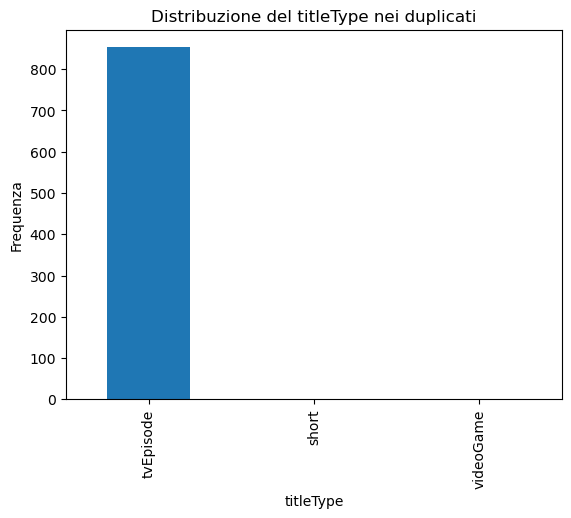

In [349]:
import matplotlib.pyplot as plt
 
title_type_distribution.plot(kind='bar')
plt.title('Distribuzione del titleType nei duplicati')
plt.xlabel('titleType')
plt.ylabel('Frequenza')
plt.show()

In [350]:
# Definisci le colonne su cui controllare i duplicati (escludendo alcune)
subset_cols = [col for col in df.columns if col not in ['countryOfOrigin', 'genres', 'originalTitle']]
 
# Mantieni solo la prima occorrenza dei duplicati
df= df[~df.duplicated(subset=subset_cols, keep='first')]

In [351]:
df[df.duplicated(subset=[col for col in df.columns if col not in ['countryOfOrigin', 'genres', 'originalTitle']], keep=False)]

,originalTitle,rating,startYear,endYear,runtimeMinutes,awardWins,numVotes,worstRating,bestRating,totalImages,...,genres,castNumber,companiesNumber,averageRating,regions,externalLinks,writerCredits,directorsCredits,soundMixes,quotesTotal


## TRASFORMAZIONI

### Gestione valori "runtimeMinutes" (verranno imputati con un regressore)

In [352]:
df.loc[df["runtimeMinutes"] == r"\N", "runtimeMinutes"] = np.nan

In [353]:
df["runtimeMinutes"].isna().sum()

39824

### Gestione valori "genres" (ha dei valori nulli che qui non vengono mostrati perchè sono codificati con \N)

In [354]:
# #trasformiamo generi in lista di stringhe
df['genres'] = df['genres'].apply(lambda x: x.split(',') if isinstance(x, str) else [])

In [355]:
df["genres"].value_counts()

genres
[Comedy]                          12956
[Drama]                           11891
[Documentary]                      7111
[Action, Adventure, Animation]     4419
[Drama, Romance]                   3144
                                  ...  
[Action, History, Horror]             1
[Biography, Horror]                   1
[Drama, Fantasy, Sport]               1
[Adventure, News]                     1
[Adult, Reality-TV, Romance]          1
Name: count, Length: 1419, dtype: int64

In [356]:
df["genres"].isna().sum()

0

### Gestione valori "countryOfOrigin" (verranno imputati con un classificatore)

In [357]:
# #trasformiamo paesi in liste di stringhe
df['countryOfOrigin'] = df['countryOfOrigin'].apply(
    lambda x: ast.literal_eval(x) if isinstance(x, str) else np.nan
)

In [358]:
df["countryOfOrigin"].value_counts()

countryOfOrigin
[US]                            44670
[GB]                            10125
[JP]                             5173
[IN]                             4004
[FR]                             3672
                                ...  
[AU, DE]                            1
[CA, FI]                            1
[GB, RO]                            1
[US, CN, TW, LU, CA]                1
[FR, BE, DE, CH, LU, IR, LB]        1
Name: count, Length: 2661, dtype: int64

In [359]:
df["countryOfOrigin"].isna().sum()

39617

### Creazione "totalMedia"

In [360]:
df["totalMedia"] = df["totalImages"] + df["totalVideos"]

In [361]:
df["totalMedia"]

0          2
1          2
2          1
3          3
4         12
          ..
149526     0
149527     5
149528     5
149529     1
149530     3
Name: totalMedia, Length: 149020, dtype: int64

### Creazione "totalNominations"

In [362]:
df["totalNominations"] = df["awardWins"] + df["awardNominationsExcludeWins"]

In [363]:
df["totalNominations"]

0         0
1         0
2         0
3         1
4         0
         ..
149526    0
149527    3
149528    0
149529    0
149530    0
Name: totalNominations, Length: 149020, dtype: int64

### Drop iniziale delle colonne

In [364]:
df = df.drop(["endYear", "bestRating", "worstRating", "isRatable", "soundMixes", "regions", "totalImages", "totalVideos", "awardWins", "awardNominationsExcludeWins"], axis=1)

### Correlation analysis

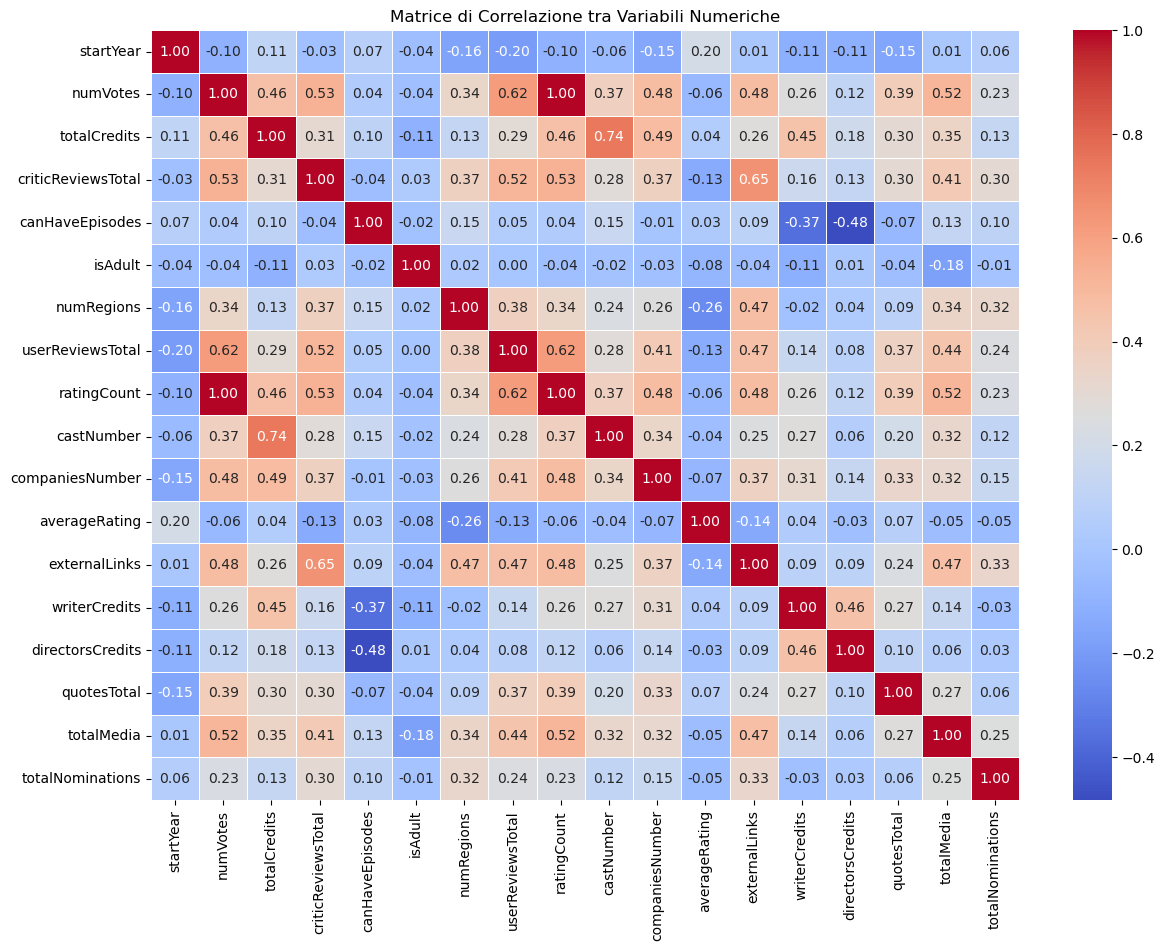

In [365]:
correlation_matrix = df.corr(method='spearman', numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Matrice di Correlazione tra Variabili Numeriche')
plt.show()

### Drop delle colonne dopo correlation analysis

In [366]:
df = df.drop(["ratingCount", "castNumber"], axis=1)

### Featuring engineering colonne


In [367]:
df

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,canHaveEpisodes,isAdult,...,countryOfOrigin,genres,companiesNumber,averageRating,externalLinks,writerCredits,directorsCredits,quotesTotal,totalMedia,totalNominations
0,Carmencita,"(5, 6]",1894,1,2089,4,3,short,False,0,...,[US],"[Documentary, Short]",3,5.7,9,0,1,0,2,0
1,Un bon bock,"(5, 6]",1892,12,183,2,0,short,False,0,...,[FR],"[Animation, Short]",0,5.4,3,0,1,0,2,0
2,Chinese Opium Den,"(4, 5]",1894,1,195,1,0,short,False,0,...,[US],[Short],1,5.0,4,0,1,0,1,0
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,1,2237,4,2,short,False,0,...,[US],"[Documentary, Short]",6,5.4,6,0,1,0,3,1
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,1,13115,11,16,short,False,0,...,[FR],"[Documentary, Short]",5,7.4,21,0,2,0,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149526,Nuestra película,"(6, 7]",1993,96,11,11,0,movie,False,0,...,[CO],[Documentary],2,7.0,1,1,1,0,0,0
149527,Eco,"(6, 7]",2019,14,15,52,1,short,False,0,...,[ES],"[Drama, Short]",3,6.4,5,1,1,0,5,3
149528,Women Take Center Stage,"(5, 6]",2019,NaN,12,32,0,tvEpisode,False,0,...,NaN,[Reality-TV],0,5.6,0,0,0,0,5,0
149529,Horrid Henry and the Christening Crisis,"(7, 8]",2011,10,9,15,0,tvEpisode,False,0,...,NaN,"[Adventure, Animation, Comedy]",0,7.1,0,3,1,0,1,0


#### gestione countryoforigin (raggruppamento per continenti)

In [368]:
HISTORIC_CODES = {
    # Europa
    'XYU': {'name': 'Yugoslavia', 'continent': 'Europe'},
    'YUCS': {'name': 'Yugoslavia (Socialist Federal Republic)', 'continent': 'Europe'},
    'YUG': {'name': 'Yugoslavia', 'continent': 'Europe'},
    'SUHH': {'name': 'Soviet Union', 'continent': 'Europe'},
    'SUN': {'name': 'Soviet Union', 'continent': 'Europe'},
    'SU': {'name': 'Soviet Union', 'continent': 'Europe'},
    'USSR': {'name': 'Union of Soviet Socialist Republics', 'continent': 'Europe'},
    'DDDE': {'name': 'East Germany', 'continent': 'Europe'},
    'DDR': {'name': 'German Democratic Republic', 'continent': 'Europe'},
    'XWG': {'name': 'East Germany', 'continent': 'Europe'},
    'BRD': {'name': 'Federal Republic of Germany (West Germany)', 'continent': 'Europe'},
    'FRGG': {'name': 'West Germany', 'continent': 'Europe'},
    'CSXX': {'name': 'Czechoslovakia', 'continent': 'Europe'},
    'CSHH': {'name': 'Czechoslovakia', 'continent': 'Europe'},
    'CSK': {'name': 'Czechoslovakia', 'continent': 'Europe'},
    'TCH': {'name': 'Czechoslovakia', 'continent': 'Europe'},
    'XCZ': {'name': 'Czechoslovakia (1945-1992)', 'continent': 'Europe'},
    'SCG': {'name': 'Serbia and Montenegro', 'continent': 'Europe'},
    'SCGN': {'name': 'Serbia and Montenegro', 'continent': 'Europe'},
    'XKV': {'name': 'Kosovo', 'continent': 'Europe'},
    'XPL': {'name': 'Poland (1945-1989)', 'continent': 'Europe'},
    'XHU': {'name': 'Hungary (1945-1989)', 'continent': 'Europe'},
    'XEU': {'name': 'European Union', 'continent': 'Europe'},
    'EUE': {'name': 'European Union', 'continent': 'Europe'},
    'XCI': {'name': 'Channel Islands', 'continent': 'Europe'},
    'XES': {'name': 'Estonia (pre-1991)', 'continent': 'Europe'},
    'XLV': {'name': 'Latvia (pre-1991)', 'continent': 'Europe'},
    'XLT': {'name': 'Lithuania (pre-1991)', 'continent': 'Europe'},
    'XAZ': {'name': 'Azores', 'continent': 'Europe'},
    'XFR': {'name': 'France (Historical)', 'continent': 'Europe'},
    'FXX': {'name': 'Metropolitan France', 'continent': 'Europe'},
    'AHU': {'name': 'Austria-Hungary', 'continent': 'Europe'},
    'PRU': {'name': 'Prussia', 'continent': 'Europe'},
    'BAV': {'name': 'Bavaria', 'continent': 'Europe'},
    'KPS': {'name': 'Kingdom of the Two Sicilies', 'continent': 'Europe'},
    'VEN': {'name': 'Republic of Venice', 'continent': 'Europe'},
    'XOH': {'name': 'Ottoman Hungary', 'continent': 'Europe'},
    'XCR': {'name': 'Crimean Khanate', 'continent': 'Europe'},
    'MON': {'name': 'Montenegro (pre-independence)', 'continent': 'Europe'},
    'VA': {'name': 'Vatican City State', 'continent': 'Europe'},
    'SRB': {'name': 'Kingdom of Serbia', 'continent': 'Europe'},
    'PDM': {'name': 'Piedmont-Sardinia', 'continent': 'Europe'},
    'XPP': {'name': 'Papal States', 'continent': 'Europe'},
    'XMO': {'name': 'Monaco (Historical)', 'continent': 'Europe'},
    'XSM': {'name': 'San Marino (Historical)', 'continent': 'Europe'},
    'XLI': {'name': 'Liechtenstein (Historical)', 'continent': 'Europe'},

    # Asia
    'ANT': {'name': 'Netherlands Antilles', 'continent': 'North_America'},
    'ANHH': {'name': 'Netherlands Antilles', 'continent': 'North_America'},
    'XAN': {'name': 'Netherlands Antilles', 'continent': 'North_America'},
    'BUR': {'name': 'Burma (now Myanmar)', 'continent': 'Asia'},
    'TPE': {'name': 'Chinese Taipei (Taiwan)', 'continent': 'Asia'},
    'XIR': {'name': 'Persia (now Iran)', 'continent': 'Asia'},
    'TMP': {'name': 'East Timor (pre-independence)', 'continent': 'Asia'},
    'TLS': {'name': 'East Timor', 'continent': 'Asia'},
    'XTI': {'name': 'East Timor (Portuguese Timor)', 'continent': 'Asia'},
    'YMD': {'name': 'South Yemen (People\'s Democratic Republic)', 'continent': 'Asia'},
    'YMN': {'name': 'North Yemen (Yemen Arab Republic)', 'continent': 'Asia'},
    'XHK': {'name': 'Hong Kong (pre-1997)', 'continent': 'Asia'},
    'HKJ': {'name': 'Hashemite Kingdom of Jordan', 'continent': 'Asia'},
    'XNA': {'name': 'Neutral Zone (Saudi Arabia-Iraq)', 'continent': 'Asia'},
    'XEA': {'name': 'East Asia (historical region)', 'continent': 'Asia'},
    'XSE': {'name': 'Southeast Asia (historical region)', 'continent': 'Asia'},
    'XME': {'name': 'Middle East (region)', 'continent': 'Asia'},
    'XIO': {'name': 'British Indian Ocean Territory', 'continent': 'Asia'},
    'XSI': {'name': 'Sikkim (now part of India)', 'continent': 'Asia'},
    #'XEG': {'name': 'United Arab Republic (Egypt & Syria)', 'continent': 'Africa/Asia'},
    'XMB': {'name': 'Manchukuo (Japanese puppet state in Manchuria)', 'continent': 'Asia'},
    'KOR': {'name': 'Korea (pre-division)', 'continent': 'Asia'},
    'XSM': {'name': 'Siam (now Thailand)', 'continent': 'Asia'},
    'XCY': {'name': 'Ceylon (now Sri Lanka)', 'continent': 'Asia'},
    'SAA': {'name': 'Sarawak (pre-Malaysia)', 'continent': 'Asia'},
    'SBH': {'name': 'North Borneo (now Sabah)', 'continent': 'Asia'},
    'XPH': {'name': 'Philippines (American period)', 'continent': 'Asia'},
    'XIN': {'name': 'British India', 'continent': 'Asia'},
    'GBG': {'name': 'Great Burhan Regime (Afghanistan)', 'continent': 'Asia'},
    'XPL': {'name': 'Palestine (British Mandate)', 'continent': 'Asia'},
    'XFI': {'name': 'French Indochina', 'continent': 'Asia'},
    'XDP': {'name': 'Portuguese India', 'continent': 'Asia'},
    'XMO': {'name': 'Macao (pre-1999)', 'continent': 'Asia'},
    'XQG': {'name': 'Qing Dynasty China', 'continent': 'Asia'},

    # Africa
    'RHO': {'name': 'Rhodesia (now Zimbabwe)', 'continent': 'Africa'},
    'XRH': {'name': 'Southern Rhodesia', 'continent': 'Africa'},
    'ZAR': {'name': 'Zaire (now Democratic Republic of the Congo)', 'continent': 'Africa'},
    'XAF': {'name': 'Afars and Issas (now Djibouti)', 'continent': 'Africa'},
    'XDY': {'name': 'Dahomey (now Benin)', 'continent': 'Africa'},
    'XUG': {'name': 'Uganda (pre-1962)', 'continent': 'Africa'},
    'XET': {'name': 'Ethiopia (pre-1993)', 'continent': 'Africa'},
    'XSU': {'name': 'Sudan (pre-2011)', 'continent': 'Africa'},
    'USR': {'name': 'Upper Volta (now Burkina Faso)', 'continent': 'Africa'},
    'XVO': {'name': 'Upper Volta', 'continent': 'Africa'},
    'XBF': {'name': 'Burkina Faso (1984-present)', 'continent': 'Africa'},
    'XLI': {'name': 'Libya (pre-2011)', 'continent': 'Africa'},
    'XTC': {'name': 'Tanganyika (now part of Tanzania)', 'continent': 'Africa'},
    'XZR': {'name': 'Zanzibar (now part of Tanzania)', 'continent': 'Africa'},
    'XTZ': {'name': 'Tanzania (1964-present)', 'continent': 'Africa'},
    'XGH': {'name': 'Gold Coast (now Ghana)', 'continent': 'Africa'},
    'XSL': {'name': 'Sierra Leone (pre-1961)', 'continent': 'Africa'},
    'XMA': {'name': 'Madeira', 'continent': 'Africa'},
    'XTA': {'name': 'Tangier International Zone', 'continent': 'Africa'},
    'XCV': {'name': 'Cape Verde (before 2013)', 'continent': 'Africa'},
    'XBI': {'name': 'British Somaliland', 'continent': 'Africa'},
    'XIF': {'name': 'Italian Somaliland', 'continent': 'Africa'},
    'XAL': {'name': 'Algérie française (French Algeria)', 'continent': 'Africa'},
    'XNY': {'name': 'Nyasaland (now Malawi)', 'continent': 'Africa'},
    'XBE': {'name': 'Belgian Congo', 'continent': 'Africa'},
    'XBA': {'name': 'Basutoland (now Lesotho)', 'continent': 'Africa'},
    'XSW': {'name': 'South West Africa (now Namibia)', 'continent': 'Africa'},
    'XZB': {'name': 'Zambezi (colonial term)', 'continent': 'Africa'},
    'XAO': {'name': 'Angola (Portuguese colony)', 'continent': 'Africa'},
    'EH': {'name': 'Western Sahara (Sahara Occidental)', 'continent': 'Africa'},
    'XEN': {'name': 'Emirates of North Africa', 'continent': 'Africa'},
    'XTR': {'name': 'Tripolitania (now part of Libya)', 'continent': 'Africa'},
    'XCY': {'name': 'Cyrenaica (now part of Libya)', 'continent': 'Africa'},
    'XAB': {'name': 'Abyssinia (historical Ethiopia)', 'continent': 'Africa'},
    'XBB': {'name': 'Bechuanaland (now Botswana)', 'continent': 'Africa'},
    'XMA': {'name': 'Madagascar (French colony)', 'continent': 'Africa'},
    'XMO': {'name': 'Morocco (French/Spanish protectorate)', 'continent': 'Africa'},
    'XTU': {'name': 'Tunisia (French protectorate)', 'continent': 'Africa'},

    # Americas
    'XUS': {'name': 'United States (Historical)', 'continent': 'North_America'},
    'XCA': {'name': 'Canada (Historical)', 'continent': 'North_America'},
    'XPU': {'name': 'Panama Canal Zone', 'continent': 'North_America'},
    'XMX': {'name': 'Mexico (Historical)', 'continent': 'North_America'},
    'XBR': {'name': 'Brazil (Historical)', 'continent': 'South_America'},
    'XAR': {'name': 'Argentina (Historical)', 'continent': 'South_America'},
    'XCB': {'name': 'Caribbean Islands (collective)', 'continent': 'North_America'},
    'XCL': {'name': 'Chile (pre-1990)', 'continent': 'South_America'},
    'XCO': {'name': 'Colombia (pre-1991)', 'continent': 'South_America'},
    'XCU': {'name': 'Cuba (pre-1959)', 'continent': 'North_America'},
    'XEN': {'name': 'English Caribbean Islands', 'continent': 'North_America'},
    'XFR': {'name': 'French Caribbean Islands', 'continent': 'North_America'},
    'XGL': {'name': 'Greenland (pre-1979)', 'continent': 'North_America'},
    'XGY': {'name': 'Guyana (British Guiana)', 'continent': 'South_America'},
    'XSR': {'name': 'Suriname (Dutch Guiana)', 'continent': 'South_America'},
    'XGF': {'name': 'French Guiana (Historical)', 'continent': 'South_America'},
    'XPI': {'name': 'Saint-Pierre and Miquelon', 'continent': 'North_America'},
    'USC': {'name': 'Confederate States of America', 'continent': 'North_America'},
    'XTX': {'name': 'Republic of Texas', 'continent': 'North_America'},
    'XHT': {'name': 'Saint-Domingue (now Haiti)', 'continent': 'North_America'},
    'XBH': {'name': 'British Honduras (now Belize)', 'continent': 'North_America'},
    'XBW': {'name': 'British West Indies', 'continent': 'North_America'},
    'XUN': {'name': 'United Provinces of Central America', 'continent': 'North_America'},
    'XGP': {'name': 'Gran Colombia', 'continent': 'South_America'},
    'XPR': {'name': 'Peru-Bolivian Confederation', 'continent': 'South_America'},
    'XPN': {'name': 'Panama (as part of Colombia)', 'continent': 'North_America'},
    'XRI': {'name': 'Río de la Plata (Viceroyalty)', 'continent': 'South_America'},
    'XLN': {'name': 'New Granada (Viceroyalty)', 'continent': 'South_America'},
    'XNS': {'name': 'New Spain (Viceroyalty)', 'continent': 'North_America'},
    'XBE': {'name': 'British Empire in America', 'continent': 'North_America'},
    'XDW': {'name': 'Danish West Indies (now US Virgin Islands)', 'continent': 'North_America'},

    # Oceania
    'XAU': {'name': 'Australia (pre-Federation)', 'continent': 'Oceania'},
    'XNZ': {'name': 'New Zealand (pre-1907)', 'continent': 'Oceania'},
    'PCI': {'name': 'Pacific Islands Trust Territory', 'continent': 'Oceania'},
    'XPI': {'name': 'Pacific Islands (US Trust Territory)', 'continent': 'Oceania'},
    'XFJ': {'name': 'Fiji (pre-1970)', 'continent': 'Oceania'},
    'XPN': {'name': 'Papua New Guinea (pre-1975)', 'continent': 'Oceania'},
    'XPW': {'name': 'Palau (pre-1994)', 'continent': 'Oceania'},
    'XMH': {'name': 'Marshall Islands (pre-1986)', 'continent': 'Oceania'},
    'XFM': {'name': 'Federated States of Micronesia (pre-1986)', 'continent': 'Oceania'},
    'XGE': {'name': 'Gilbert Islands (now part of Kiribati)', 'continent': 'Oceania'},
    'XEL': {'name': 'Ellice Islands (now Tuvalu)', 'continent': 'Oceania'},
    'XNH': {'name': 'New Hebrides (now Vanuatu)', 'continent': 'Oceania'},
    'PCT': {'name': 'Pacific Islands Trust Territory', 'continent': 'Oceania'},
    'XWS': {'name': 'Western Samoa (now Samoa)', 'continent': 'Oceania'},
    'XNA': {'name': 'Netherlands New Guinea', 'continent': 'Oceania'},
    'XHS': {'name': 'Hawaii (pre-US statehood)', 'continent': 'Oceania'},
    'XBP': {'name': 'British Polynesia', 'continent': 'Oceania'},
    'XFP': {'name': 'French Polynesia (historical)', 'continent': 'Oceania'},
    'XNC': {'name': 'New Caledonia (historical)', 'continent': 'Oceania'},
    'XSI': {'name': 'Solomon Islands (British protectorate)', 'continent': 'Oceania'},

}

In [369]:
# !pip install pycountry_convert

In [370]:
import pycountry
import pycountry_convert as pc


def get_continent(country_code):
    """Ottiene il continente per una singola sigla di paese"""
    # Controlla prima nel dizionario storico
    if country_code in HISTORIC_CODES:
        return HISTORIC_CODES[country_code]['continent']

    try:
        # Per codici a 2 lettere (alpha-2)
        if len(country_code) == 2:
            country_continent_code = pc.country_alpha2_to_continent_code(country_code)
            continent_name = pc.convert_continent_code_to_continent_name(country_continent_code)
            return continent_name

        # Per codici a 3 lettere (alpha-3)
        elif len(country_code) == 3:
            # Converti da alpha-3 a alpha-2
            country = pycountry.countries.get(alpha_3=country_code)
            if country:
                country_alpha2 = country.alpha_2
                country_continent_code = pc.country_alpha2_to_continent_code(country_alpha2)
                continent_name = pc.convert_continent_code_to_continent_name(country_continent_code)
                return continent_name

        # Controlla nei paesi storici di pycountry
        historic = next((c for c in pycountry.historic_countries if c.alpha_3 == country_code), None)
        if historic:
            return map_historic_to_continent(historic.name)

        return None
    except (KeyError, ValueError, AttributeError):
        return None

def get_continents_for_list(country_codes):
    """Gestisce una lista di sigle di paesi e restituisce un dizionario con i risultati"""
    results = {}

    # Se l'input è una singola stringa, convertila in lista
    if isinstance(country_codes, str):
        country_codes = [country_codes]

    # Elabora ogni sigla nella lista
    for code in country_codes:
        results[code] = get_continent(code)

    return results

def map_historic_to_continent(country_name):
    """Mappa manuale di alcuni paesi storici ai loro continenti"""
    mappings = {
        'USSR': 'Europe',
        'YUGOSLAVIA': 'Europe',
        'CZECHOSLOVAKIA': 'Europe',
        # Aggiungi altri paesi storici secondo necessità
    }

    for key, value in mappings.items():
        if key in country_name.upper():
            return value

    return None

# utilizzo con lista
all_countries = set(country for sublist in df['countryOfOrigin'] if isinstance(sublist, list) for country in sublist)
continent_mapping = get_continents_for_list(all_countries)
continent_mapping

{'IT': 'Europe',
 'AW': 'North America',
 'KW': 'Asia',
 'EC': 'South America',
 'GM': 'Africa',
 'BH': 'Asia',
 'NI': 'North America',
 'BY': 'Europe',
 'RO': 'Europe',
 'LU': 'Europe',
 'CR': 'North America',
 'HN': 'North America',
 'MA': 'Africa',
 'AF': 'Asia',
 'LR': 'Africa',
 'BT': 'Asia',
 'KM': 'Africa',
 'DK': 'Europe',
 'MC': 'Europe',
 'CF': 'Africa',
 'MW': 'Africa',
 'TT': 'North America',
 'MN': 'Asia',
 'AG': 'North America',
 'CC': 'Asia',
 'NG': 'Africa',
 'ID': 'Asia',
 'LS': 'Africa',
 'UZ': 'Asia',
 'MQ': 'North America',
 'CH': 'Europe',
 'AO': 'Africa',
 'CG': 'Africa',
 'NE': 'Africa',
 'CSXX': 'Europe',
 'ZW': 'Africa',
 'CM': 'Africa',
 'LA': 'Asia',
 'AT': 'Europe',
 'AZ': 'Asia',
 'ME': 'Europe',
 'DO': 'North America',
 'DZ': 'Africa',
 'MD': 'Europe',
 'TH': 'Asia',
 'TZ': 'Africa',
 'SG': 'Asia',
 'SY': 'Asia',
 'GP': 'North America',
 'TW': 'Asia',
 'GD': 'North America',
 'GW': 'Africa',
 'EE': 'Europe',
 'TN': 'Africa',
 'TM': 'Asia',
 'SUHH': 'Europe

In [371]:
df[df['countryOfOrigin'].apply(lambda x: isinstance(x, float))]['countryOfOrigin']

254       NaN
5965      NaN
7017      NaN
11450     NaN
15021     NaN
         ... 
149523    NaN
149525    NaN
149528    NaN
149529    NaN
149530    NaN
Name: countryOfOrigin, Length: 39617, dtype: object

In [372]:
print("Totale valori float:", df['countryOfOrigin'].apply(lambda x: isinstance(x, float)).sum())

Totale valori float: 39617


In [373]:
df_nan_country = df[df['countryOfOrigin'].isna()].copy()

In [374]:
df.dropna(subset=['countryOfOrigin'], inplace=True)

In [375]:
def replace_country_with_continent(df, column_name, continent_mapping):
    """
    Sostituisce i codici dei paesi nella colonna di un DataFrame con il loro continente corrispondente.

    :param df: DataFrame contenente la colonna da modificare
    :param column_name: Nome della colonna con le liste di codici paese
    :param continent_mapping: Dizionario {codice_paese: continente}
    :return: DataFrame con la colonna modificata
    """
    df[column_name] = df[column_name].apply(
        lambda country_list: list(set(continent_mapping.get(country, 'Unknown') for country in country_list))
    )
    return df


# Applicazione della funzione
df3 = replace_country_with_continent(df, 'countryOfOrigin', get_continents_for_list(all_countries))

# Stampa del risultato
#print(test_df["countryOfOrigin"])


In [376]:
df3

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,canHaveEpisodes,isAdult,...,countryOfOrigin,genres,companiesNumber,averageRating,externalLinks,writerCredits,directorsCredits,quotesTotal,totalMedia,totalNominations
0,Carmencita,"(5, 6]",1894,1,2089,4,3,short,False,0,...,[North America],"[Documentary, Short]",3,5.7,9,0,1,0,2,0
1,Un bon bock,"(5, 6]",1892,12,183,2,0,short,False,0,...,[Europe],"[Animation, Short]",0,5.4,3,0,1,0,2,0
2,Chinese Opium Den,"(4, 5]",1894,1,195,1,0,short,False,0,...,[North America],[Short],1,5.0,4,0,1,0,1,0
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,1,2237,4,2,short,False,0,...,[North America],"[Documentary, Short]",6,5.4,6,0,1,0,3,1
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,1,13115,11,16,short,False,0,...,[Europe],"[Documentary, Short]",5,7.4,21,0,2,0,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149512,Aunty Donna: Trendy,"(8, 9]",2016,5,37,18,0,tvSeries,True,0,...,[Oceania],[Comedy],2,8.3,1,0,0,0,7,0
149514,DK Bose,"(5, 6]",2019,117,15,11,0,movie,False,0,...,[Asia],[Comedy],1,5.8,1,1,1,0,11,0
149524,Earth: Population Overload,"(5, 6]",2018,66,16,1,0,video,False,0,...,[North America],[Documentary],2,6.0,3,0,0,0,1,0
149526,Nuestra película,"(6, 7]",1993,96,11,11,0,movie,False,0,...,[South America],[Documentary],2,7.0,1,1,1,0,0,0


In [377]:
df3["countryOfOrigin"].value_counts()

countryOfOrigin
[North America]                                                  49827
[Europe]                                                         35242
[Asia]                                                           15532
[South America]                                                   2173
[Oceania]                                                         2052
[Europe, North America]                                           1776
[Africa]                                                           810
[North America, Asia]                                              453
[Europe, Asia]                                                     439
[South America, Europe]                                            182
[Europe, Africa]                                                   152
[Europe, North America, Asia]                                      146
[South America, North America]                                     127
[Oceania, North America]                                     

In [378]:
df3[df3["countryOfOrigin"].apply(lambda x: None in x if isinstance(x, list) else False)]

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,canHaveEpisodes,isAdult,...,countryOfOrigin,genres,companiesNumber,averageRating,externalLinks,writerCredits,directorsCredits,quotesTotal,totalMedia,totalNominations
33579,Chi Nhung,"(6, 7]",1970,66,15,11,0,movie,False,0,...,[None],"[Drama, War]",1,6.8,1,1,2,0,2,2
66492,Jiwonbyeong,"(5, 6]",1941,56,29,20,2,movie,False,0,...,[None],[Drama],2,6.0,3,1,1,0,1,0
86662,Chopin. I Am Not Afraid of Darkness,"(8, 9]",2022,60,10,28,6,movie,False,0,...,"[Europe, None]","[Documentary, Music]",4,8.1,11,1,3,0,13,0
110872,Im Lande der Morgenstille,"(6, 7]",1925,117,13,1,0,movie,False,0,...,"[Europe, None]",[Documentary],1,6.7,1,0,1,0,1,0
115041,Cheongchun-eui sipjaro,"(5, 6]",1934,73,29,12,0,movie,False,0,...,[None],[\N],2,5.8,2,1,1,0,1,0


In [379]:
import pandas as pd

# Supponiamo df3 sia il DataFrame principale
# df_target è quello su cui vuoi aggiungere le istanze con "None"

# Step 1: crea una copia di df3 per lavorarci
df3_cleaned = df3.copy()

# Step 2: Se una riga ha sia "None" e "Europe" → rimuovi "None"
def clean_country_list(x):
    if isinstance(x, list):
        x_cleaned = [v for v in x if v != None]
        return x_cleaned if x_cleaned else [None]  # fallback se solo "None"
    return x

df3_cleaned["countryOfOrigin"] = df3_cleaned["countryOfOrigin"].apply(clean_country_list)

# Step 3: Filtra le righe che contengono ancora "None"
df_with_none = df3_cleaned[df3_cleaned["countryOfOrigin"].apply(lambda x: None in x if isinstance(x, list) else False)]

# Step 4: Aggiungi queste righe a un altro DataFrame esistente
# Supponiamo tu abbia df_target:
df_nan_country = pd.concat([df_nan_country, df_with_none], ignore_index=True)


In [380]:
print(df_with_none.shape)

(3, 22)


In [381]:
df_nan_country.shape

(39620, 22)

In [382]:
df_nan_country.isnull().sum()

originalTitle             0
rating                    0
startYear                 0
runtimeMinutes        19778
numVotes                  0
totalCredits              0
criticReviewsTotal        0
titleType                 0
canHaveEpisodes           0
isAdult                   0
numRegions                0
userReviewsTotal          0
countryOfOrigin       39617
genres                    0
companiesNumber           0
averageRating             0
externalLinks             0
writerCredits             0
directorsCredits          0
quotesTotal               0
totalMedia                0
totalNominations          0
dtype: int64

In [383]:
# Step 4: Rimuovi i valori None dalle liste in df3_cleaned["countryOfOrigin"]
def remove_none(x):
    if isinstance(x, list):
        return [v for v in x if v is not None]
    return x

df3_cleaned["countryOfOrigin"] = df3_cleaned["countryOfOrigin"].apply(remove_none)

In [384]:
df3_cleaned[df3_cleaned["countryOfOrigin"].apply(lambda x: None in x if isinstance(x, list) else False)]

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,canHaveEpisodes,isAdult,...,countryOfOrigin,genres,companiesNumber,averageRating,externalLinks,writerCredits,directorsCredits,quotesTotal,totalMedia,totalNominations


In [385]:
df3_cleaned

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,canHaveEpisodes,isAdult,...,countryOfOrigin,genres,companiesNumber,averageRating,externalLinks,writerCredits,directorsCredits,quotesTotal,totalMedia,totalNominations
0,Carmencita,"(5, 6]",1894,1,2089,4,3,short,False,0,...,[North America],"[Documentary, Short]",3,5.7,9,0,1,0,2,0
1,Un bon bock,"(5, 6]",1892,12,183,2,0,short,False,0,...,[Europe],"[Animation, Short]",0,5.4,3,0,1,0,2,0
2,Chinese Opium Den,"(4, 5]",1894,1,195,1,0,short,False,0,...,[North America],[Short],1,5.0,4,0,1,0,1,0
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,1,2237,4,2,short,False,0,...,[North America],"[Documentary, Short]",6,5.4,6,0,1,0,3,1
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,1,13115,11,16,short,False,0,...,[Europe],"[Documentary, Short]",5,7.4,21,0,2,0,12,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149512,Aunty Donna: Trendy,"(8, 9]",2016,5,37,18,0,tvSeries,True,0,...,[Oceania],[Comedy],2,8.3,1,0,0,0,7,0
149514,DK Bose,"(5, 6]",2019,117,15,11,0,movie,False,0,...,[Asia],[Comedy],1,5.8,1,1,1,0,11,0
149524,Earth: Population Overload,"(5, 6]",2018,66,16,1,0,video,False,0,...,[North America],[Documentary],2,6.0,3,0,0,0,1,0
149526,Nuestra película,"(6, 7]",1993,96,11,11,0,movie,False,0,...,[South America],[Documentary],2,7.0,1,1,1,0,0,0


#

In [386]:
# Lista di valori sospetti
# Valori sospetti con raw string
valori_sospetti = [r"\n", r"\N", r"\\N", ""]

# Colonne che contengono almeno un valore sospetto
colonne_con_valori = []

for col in df3_cleaned.columns:
    # Convertiamo i valori in stringa per sicurezza
    if df3_cleaned[col].astype(str).isin(valori_sospetti).any():
        colonne_con_valori.append(col)

print("Colonne che contengono valori sospetti:", colonne_con_valori)


Colonne che contengono valori sospetti: []


In [387]:
df_nan_country.isnull().sum()

originalTitle             0
rating                    0
startYear                 0
runtimeMinutes        19778
numVotes                  0
totalCredits              0
criticReviewsTotal        0
titleType                 0
canHaveEpisodes           0
isAdult                   0
numRegions                0
userReviewsTotal          0
countryOfOrigin       39617
genres                    0
companiesNumber           0
averageRating             0
externalLinks             0
writerCredits             0
directorsCredits          0
quotesTotal               0
totalMedia                0
totalNominations          0
dtype: int64

In [388]:
df3_cleaned.head()

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,canHaveEpisodes,isAdult,...,countryOfOrigin,genres,companiesNumber,averageRating,externalLinks,writerCredits,directorsCredits,quotesTotal,totalMedia,totalNominations
0,Carmencita,"(5, 6]",1894,1,2089,4,3,short,False,0,...,[North America],"[Documentary, Short]",3,5.7,9,0,1,0,2,0
1,Un bon bock,"(5, 6]",1892,12,183,2,0,short,False,0,...,[Europe],"[Animation, Short]",0,5.4,3,0,1,0,2,0
2,Chinese Opium Den,"(4, 5]",1894,1,195,1,0,short,False,0,...,[North America],[Short],1,5.0,4,0,1,0,1,0
3,Edison Kinetoscopic Record of a Sneeze,"(5, 6]",1894,1,2237,4,2,short,False,0,...,[North America],"[Documentary, Short]",6,5.4,6,0,1,0,3,1
4,L'arrivée d'un train à La Ciotat,"(7, 8]",1896,1,13115,11,16,short,False,0,...,[Europe],"[Documentary, Short]",5,7.4,21,0,2,0,12,0


### Trasformazione  rating in intero e approsimato per eccesso in base al valore di avg rating

In [389]:
import regex as re

In [390]:
df3_cleaned['rating'] = df3_cleaned['rating'].apply(lambda x: re.sub(r"\]|\(", "", x).strip())

In [391]:
#trasformazione rating df3 senza nan in countryof origing
df3_cleaned["rating"] = np.where(
    (df3_cleaned["averageRating"] % 1) >= 0.5,
    np.floor(df3_cleaned["averageRating"]) + 1,
    np.floor(df3_cleaned["averageRating"])
).astype(int)

In [392]:
##trasformazione rating in df_nan con nan in countryof origing
df_nan_country["rating"] = np.where(
    (df_nan_country["averageRating"] % 1) >= 0.5,
    np.floor(df_nan_country["averageRating"]) + 1,
    np.floor(df_nan_country["averageRating"])
).astype(int)

In [393]:
df_nan_country.head()

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,canHaveEpisodes,isAdult,...,countryOfOrigin,genres,companiesNumber,averageRating,externalLinks,writerCredits,directorsCredits,quotesTotal,totalMedia,totalNominations
0,'Round the World in 80 Days,5,1914,NaN,41,2,0,movie,False,0,...,NaN,[Adventure],2,5.3,1,1,1,0,0,0
1,The Greatest Man in the World,8,1958,57,26,32,0,tvEpisode,False,0,...,NaN,[Drama],2,7.5,1,2,1,0,38,0
2,A Free Agent,7,1964,60,12,35,0,tvEpisode,False,0,...,NaN,"[Drama, War]",4,7.2,0,1,1,0,0,0
3,A Guide to Armageddon,9,1982,NaN,76,9,0,tvEpisode,False,0,...,NaN,[Documentary],0,8.5,0,1,1,0,3,0
4,A félelem ára,6,1993,60,6,94,0,tvEpisode,False,0,...,NaN,"[Adventure, Comedy, Crime]",0,6.0,0,3,1,0,34,0


In [394]:
df3_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109403 entries, 0 to 149527
Data columns (total 22 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   originalTitle       109403 non-null  object 
 1   rating              109403 non-null  int32  
 2   startYear           109403 non-null  int64  
 3   runtimeMinutes      89357 non-null   object 
 4   numVotes            109403 non-null  int64  
 5   totalCredits        109403 non-null  int64  
 6   criticReviewsTotal  109403 non-null  int64  
 7   titleType           109403 non-null  object 
 8   canHaveEpisodes     109403 non-null  bool   
 9   isAdult             109403 non-null  int64  
 10  numRegions          109403 non-null  int64  
 11  userReviewsTotal    109403 non-null  int64  
 12  countryOfOrigin     109403 non-null  object 
 13  genres              109403 non-null  object 
 14  companiesNumber     109403 non-null  int64  
 15  averageRating       109403 non-null  fl

In [395]:
# df3_cleaned.drop(columns=["runtimeMinutes_num"], inplace=True)
# df_nan_country.drop(columns=["runtimeMinutes_num"], inplace=True)

In [396]:
# #Trasfromazione in intero di runtimeMinutes
# df3_cleaned['runtimeMinutes_num'] = pd.to_numeric(df3_cleaned['runtimeMinutes'], errors='coerce')
# df_nan_country['runtimeMinutes_num'] = pd.to_numeric(df_nan_country['runtimeMinutes'], errors='coerce')

In [397]:
#Trasfromazione in intero di runtimeMinutes
df3_cleaned['runtimeMinutes'] = pd.to_numeric(df3_cleaned['runtimeMinutes'], errors='coerce')
df_nan_country['runtimeMinutes'] = pd.to_numeric(df_nan_country['runtimeMinutes'], errors='coerce')


In [398]:
print(df3_cleaned["runtimeMinutes"].dtype)


float64


In [399]:
df3_cleaned.head()

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,titleType,canHaveEpisodes,isAdult,...,countryOfOrigin,genres,companiesNumber,averageRating,externalLinks,writerCredits,directorsCredits,quotesTotal,totalMedia,totalNominations
0,Carmencita,6,1894,1.0,2089,4,3,short,False,0,...,[North America],"[Documentary, Short]",3,5.7,9,0,1,0,2,0
1,Un bon bock,5,1892,12.0,183,2,0,short,False,0,...,[Europe],"[Animation, Short]",0,5.4,3,0,1,0,2,0
2,Chinese Opium Den,5,1894,1.0,195,1,0,short,False,0,...,[North America],[Short],1,5.0,4,0,1,0,1,0
3,Edison Kinetoscopic Record of a Sneeze,5,1894,1.0,2237,4,2,short,False,0,...,[North America],"[Documentary, Short]",6,5.4,6,0,1,0,3,1
4,L'arrivée d'un train à La Ciotat,7,1896,1.0,13115,11,16,short,False,0,...,[Europe],"[Documentary, Short]",5,7.4,21,0,2,0,12,0


### onehotencoding genres

In [400]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Crea una copia del DataFrame
df_encoded = df3_cleaned.copy()

# Istanzia il binarizzatore
mlb = MultiLabelBinarizer()

# Applica l'encodering alla colonna "genres"
genre_encoded = mlb.fit_transform(df_encoded["genres"])

# Aggiungi prefisso 'genres_' ai nomi delle colonne
column_names = [f"genres_{genre}" for genre in mlb.classes_]

# Crea un DataFrame con le nuove colonne
df_genre_encoded = pd.DataFrame(genre_encoded, columns=column_names, index=df_encoded.index)

# Unisci le colonne al DataFrame originale
df_encoded = pd.concat([df_encoded, df_genre_encoded], axis=1)

# (Opzionale) Rimuovi la colonna originale
df_encoded.drop(columns=["genres"], inplace=True)


In [401]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Crea una copia del DataFrame
df_encoded_nan = df_nan_country.copy()

# Istanzia il binarizzatore
mlb = MultiLabelBinarizer()

# Applica l'encodering alla colonna "genres"
genre_encoded = mlb.fit_transform(df_encoded_nan["genres"])

# Aggiungi prefisso 'genres_' ai nomi delle colonne
column_names = [f"genres_{genre}" for genre in mlb.classes_]

# Crea un DataFrame con le nuove colonne
df_genre_encoded = pd.DataFrame(genre_encoded, columns=column_names, index=df_encoded_nan.index)

# Unisci le colonne al DataFrame originale
df_encoded_nan = pd.concat([df_encoded_nan, df_genre_encoded], axis=1)

# (Opzionale) Rimuovi la colonna originale
df_encoded_nan.drop(columns=["genres"], inplace=True)


### multilabelencoding country (in df_nan non serve)

In [402]:
from sklearn.preprocessing import MultiLabelBinarizer
import pandas as pd

# Crea una copia del DataFrame
df_encoded = df_encoded.copy()

# Istanzia il binarizzatore
mlb = MultiLabelBinarizer()

# Applica l'encodering alla colonna "genres"
continent_encoded = mlb.fit_transform(df_encoded["countryOfOrigin"])

# Aggiungi prefisso 'from' ai nomi delle colonne
column_names = [f"from_{genre}" for genre in mlb.classes_]

# Crea un DataFrame con le nuove colonne
df_continent_encoded = pd.DataFrame(continent_encoded, columns=column_names, index=df_encoded.index)

# Unisci le colonne al DataFrame originale
df_encoded = pd.concat([df_encoded, df_continent_encoded], axis=1)

# (Opzionale) Rimuovi la colonna originale
df_encoded.drop(columns=["countryOfOrigin"], inplace=True)


In [403]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109403 entries, 0 to 149527
Data columns (total 55 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   originalTitle       109403 non-null  object 
 1   rating              109403 non-null  int32  
 2   startYear           109403 non-null  int64  
 3   runtimeMinutes      89357 non-null   float64
 4   numVotes            109403 non-null  int64  
 5   totalCredits        109403 non-null  int64  
 6   criticReviewsTotal  109403 non-null  int64  
 7   titleType           109403 non-null  object 
 8   canHaveEpisodes     109403 non-null  bool   
 9   isAdult             109403 non-null  int64  
 10  numRegions          109403 non-null  int64  
 11  userReviewsTotal    109403 non-null  int64  
 12  companiesNumber     109403 non-null  int64  
 13  averageRating       109403 non-null  float64
 14  externalLinks       109403 non-null  int64  
 15  writerCredits       109403 non-null  in

In [404]:
df_encoded.duplicated().sum()

0

### Dropping delle istanze che hanno come genere \n sia df_encoded che da df_nan_country, in quanto sono il 2% del dataset totale. Inoltre non hanno altro genere che \n

In [405]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 109403 entries, 0 to 149527
Data columns (total 55 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   originalTitle       109403 non-null  object 
 1   rating              109403 non-null  int32  
 2   startYear           109403 non-null  int64  
 3   runtimeMinutes      89357 non-null   float64
 4   numVotes            109403 non-null  int64  
 5   totalCredits        109403 non-null  int64  
 6   criticReviewsTotal  109403 non-null  int64  
 7   titleType           109403 non-null  object 
 8   canHaveEpisodes     109403 non-null  bool   
 9   isAdult             109403 non-null  int64  
 10  numRegions          109403 non-null  int64  
 11  userReviewsTotal    109403 non-null  int64  
 12  companiesNumber     109403 non-null  int64  
 13  averageRating       109403 non-null  float64
 14  externalLinks       109403 non-null  int64  
 15  writerCredits       109403 non-null  in

In [406]:
df_encoded.drop(index=df_encoded[df_encoded[r"genres_\N"] == 1].index, inplace=True)
df_encoded.drop(columns=[r"genres_\N"], inplace=True)

In [407]:
df_encoded_nan.drop(index=df_encoded_nan[df_encoded_nan[r"genres_\N"] == 1].index, inplace=True)

In [408]:
df_encoded_nan.drop(columns=[r"genres_\N", "canHaveEpisodes"], inplace=True)
df_encoded.drop(columns=["canHaveEpisodes"], inplace=True)

In [409]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106871 entries, 0 to 149527
Data columns (total 53 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   originalTitle       106871 non-null  object 
 1   rating              106871 non-null  int32  
 2   startYear           106871 non-null  int64  
 3   runtimeMinutes      88027 non-null   float64
 4   numVotes            106871 non-null  int64  
 5   totalCredits        106871 non-null  int64  
 6   criticReviewsTotal  106871 non-null  int64  
 7   titleType           106871 non-null  object 
 8   isAdult             106871 non-null  int64  
 9   numRegions          106871 non-null  int64  
 10  userReviewsTotal    106871 non-null  int64  
 11  companiesNumber     106871 non-null  int64  
 12  averageRating       106871 non-null  float64
 13  externalLinks       106871 non-null  int64  
 14  writerCredits       106871 non-null  int64  
 15  directorsCredits    106871 non-null  in

### onehotencoding titletype

In [410]:
from sklearn.preprocessing import OneHotEncoder

# Istanzia l'encoder
encoder = OneHotEncoder(sparse_output=False)  # usa sparse=False se hai sklearn < 1.2

# Trasforma la colonna "titleType" e converte in interi
encoded_array = encoder.fit_transform(df_encoded_nan[["titleType"]]).astype(int)

# Ottieni i nomi delle nuove colonne
new_columns = encoder.get_feature_names_out(["titleType"])

# Inserisci nel DataFrame originale
for col_name, col_data in zip(new_columns, encoded_array.T):
    df_encoded_nan[col_name] = col_data

# Rimuovi la colonna originale
df_encoded_nan.drop(columns=["titleType"], inplace=True)


In [411]:
from sklearn.preprocessing import OneHotEncoder

# Istanzia l'encoder
encoder = OneHotEncoder(sparse_output=False)  # usa sparse=False se hai sklearn < 1.2

# Trasforma la colonna "titleType"
encoded_array = encoder.fit_transform(df_encoded[["titleType"]]).astype(int)

# Ottieni i nomi delle nuove colonne
new_columns = encoder.get_feature_names_out(["titleType"])

# Inserisci nel DataFrame originale
for col_name, col_data in zip(new_columns, encoded_array.T):
    df_encoded[col_name] = col_data

# Rimuovi la colonna originale
df_encoded.drop(columns=["titleType"], inplace=True)

### trasformazione in numerico di runtimemins

In [412]:
df3_cleaned['runtimeMinutes'] = pd.to_numeric(df3_cleaned['runtimeMinutes'], errors='coerce')
df_nan_country['runtimeMinutes'] = pd.to_numeric(df_nan_country['runtimeMinutes'], errors='coerce')

### gestione valori none countryoforigin

In [413]:
df_encoded_nan["countryOfOrigin"] = df_encoded_nan["countryOfOrigin"].apply(
    lambda x: np.nan if isinstance(x, list) and None in x else x
)

### analisi mismatch tra indice e length

In [414]:
df_encoded_nan["countryOfOrigin"]

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
39614   NaN
39615   NaN
39616   NaN
39617   NaN
39618   NaN
Name: countryOfOrigin, Length: 39461, dtype: float64

In [415]:
df_encoded_nan = df_encoded_nan.reset_index(drop=True)

In [416]:
df_encoded_nan["countryOfOrigin"]

0       NaN
1       NaN
2       NaN
3       NaN
4       NaN
         ..
39456   NaN
39457   NaN
39458   NaN
39459   NaN
39460   NaN
Name: countryOfOrigin, Length: 39461, dtype: float64

In [417]:
df_encoded = df_encoded.reset_index(drop=True)

### gestione genres_Film-Noir

In [418]:
df_encoded["genres_Film-Noir"].value_counts()

genres_Film-Noir
0    106716
1       155
Name: count, dtype: int64

In [419]:
# Supponiamo che i tuoi DataFrame si chiamino df1 e df2

# Trova le colonne che sono in df1 ma non in df2
diff1 = set(df_encoded.columns) - set(df_encoded_nan.columns)

# Trova le colonne che sono in df2 ma non in df1
#diff2 = set(df2.columns) - set(df1.columns)

# Mostra il risultato
print("Colonne presenti solo in df1:", diff1)
#print("Colonne presenti solo in df2:", diff2)


Colonne presenti solo in df1: {'from_South America', 'genres_Film-Noir', 'from_Europe', 'from_Africa', 'from_Oceania', 'from_Asia', 'from_North America'}


In [420]:
df_encoded.drop(index=df_encoded[df_encoded["genres_Film-Noir"] == 1].index, inplace=True)

### analisi incongruenze tra genres_Short/titletype_short & isAdult/genres_Adult

In [421]:
df_encoded["genres_Short"].value_counts()

genres_Short
0    90485
1    16231
Name: count, dtype: int64

In [422]:
df_encoded["titleType_short"].value_counts()

titleType_short
0    90403
1    16313
Name: count, dtype: int64

In [423]:
df_encoded["isAdult"].value_counts()

isAdult
0    104081
1      2635
Name: count, dtype: int64

In [424]:
df_encoded["genres_Adult"].value_counts()

genres_Adult
0    104121
1      2595
Name: count, dtype: int64

In [425]:
# Trova i record dove genres_Short e titleType_short non corrispondono
incongruenze_genres_title = df_encoded[
    df_encoded['genres_Short'] != df_encoded['titleType_short']
]

print(f"Numero di incongruenze genres_Short vs titleType_short: {len(incongruenze_genres_title)}")
print("\nPrimi esempi di incongruenze:")
print(incongruenze_genres_title[['genres_Short', 'titleType_short']].head(10))

Numero di incongruenze genres_Short vs titleType_short: 3434

Primi esempi di incongruenze:
     genres_Short  titleType_short
41              0                1
45              0                1
66              0                1
71              0                1
72              0                1
74              0                1
140             0                1
457             0                1
475             0                1
847             0                1


In [426]:
# Per vedere tutti i tipi di incongruenze con conteggi
print("Analisi incongruenze genres_Short vs titleType_short:")
crosstab_genres = pd.crosstab(df_encoded['genres_Short'], 
                             df_encoded['titleType_short'], 
                             margins=True)
print(crosstab_genres)

print("\nAnalisi incongruenze isAdult vs genres_Adult:")
crosstab_adult = pd.crosstab(df_encoded['isAdult'], 
                            df_encoded['genres_Adult'], 
                            margins=True)
print(crosstab_adult)

Analisi incongruenze genres_Short vs titleType_short:
titleType_short      0      1     All
genres_Short                         
0                88727   1758   90485
1                 1676  14555   16231
All              90403  16313  106716

Analisi incongruenze isAdult vs genres_Adult:
genres_Adult       0     1     All
isAdult                           
0             104081     0  104081
1                 40  2595    2635
All           104121  2595  106716


In [427]:
# Filtra le righe con incongruenze tra genres_Adult e isAdult
incongruenze_adult = df_encoded[
    df_encoded['genres_Adult'] != df_encoded['isAdult']
]

print(f"Numero totale di incongruenze genres_Adult vs isAdult: {len(incongruenze_adult)}")
print(f"Percentuale sul totale: {len(incongruenze_adult)/len(df_encoded)*100:.2f}%")

# Identifica tutte le colonne genres_* (esclusa genres_Adult)
genres_columns = [col for col in df_encoded.columns if col.startswith('genres_') and col != 'genres_Adult']
print(f"\nColonne genres disponibili: {genres_columns}")

# Analisi dettagliata delle incongruenze
print(f"\nTipi di incongruenze:")
crosstab = pd.crosstab(df_encoded['genres_Adult'], df_encoded['isAdult'], margins=True)
print(crosstab)

# Caso 1: genres_Adult = 1 ma isAdult = 0
caso1 = df_encoded[(df_encoded['genres_Adult'] == 1) & (df_encoded['isAdult'] == 0)]
print(f"\nCaso 1 - genres_Adult=1 ma isAdult=0: {len(caso1)} record")

# Caso 2: genres_Adult = 0 ma isAdult = 1  
caso2 = df_encoded[(df_encoded['genres_Adult'] == 0) & (df_encoded['isAdult'] == 1)]
print(f"Caso 2 - genres_Adult=0 ma isAdult=1: {len(caso2)} record")

# Analizza le altre colonne genres_* per capire le incongruenze
if len(caso1) > 0:
    print(f"\nCaso 1 - Analisi altre colonne genres_*:")
    for col in genres_columns:
        count_ones = (caso1[col] == 1).sum()
        if count_ones > 0:
            print(f"  {col}: {count_ones} record con valore 1 ({count_ones/len(caso1)*100:.1f}%)")
    
    print(f"\nEsempi Caso 1:")
    colonne_esempio = ['tconst', 'titleType', 'isAdult', 'genres_Adult'] + genres_columns[:5]  # Prime 5 colonne genres
    print(caso1[colonne_esempio].head(10))

if len(caso2) > 0:
    print(f"\nCaso 2 - Analisi altre colonne genres_*:")
    for col in genres_columns:
        count_ones = (caso2[col] == 1).sum()
        if count_ones > 0:
            print(f"  {col}: {count_ones} record con valore 1 ({count_ones/len(caso2)*100:.1f}%)")
    
    print(f"\nEsempi Caso 2:")
    colonne_esempio = ['isAdult', 'genres_Adult'] + genres_columns[:5]  # Prime 5 colonne genres
    print(caso2[colonne_esempio].head(10))

# Verifica se ci sono pattern nei titleType
print(f"\nDistribuzione titleType per le incongruenze:")
print(f"Caso 1 (genres_Adult=1, isAdult=0):")
if len(caso1) > 0:
    print(caso1['titleType'].value_counts())

# print(f"\nCaso 2 (genres_Adult=0, isAdult=1):")
# if len(caso2) > 0:
#     print(caso2['titleType'].value_counts())

# # Per ogni caso, mostra la distribuzione completa delle colonne genres_*
# if len(caso1) > 0:
#     print(f"\nCaso 1 - Distribuzione completa genres_*:")
#     genres_sum_caso1 = caso1[genres_columns].sum().sort_values(ascending=False)
#     print(genres_sum_caso1[genres_sum_caso1 > 0])

# if len(caso2) > 0:
#     print(f"\nCaso 2 - Distribuzione completa genres_*:")
#     genres_sum_caso2 = caso2[genres_columns].sum().sort_values(ascending=False)
#     print(genres_sum_caso2[genres_sum_caso2 > 0])

# # Analizza runtimeMinutes per vedere se c'è una correlazione
# print(f"\nAnalisi runtimeMinutes:")
# if len(caso1) > 0:
#     print(f"Caso 1 - Media runtime: {caso1['runtimeMinutes'].mean():.2f} minuti")
# if len(caso2) > 0:
#     print(f"Caso 2 - Media runtime: {caso2['runtimeMinutes'].mean():.2f} minuti")

Numero totale di incongruenze genres_Adult vs isAdult: 40
Percentuale sul totale: 0.04%

Colonne genres disponibili: ['genres_Action', 'genres_Adventure', 'genres_Animation', 'genres_Biography', 'genres_Comedy', 'genres_Crime', 'genres_Documentary', 'genres_Drama', 'genres_Family', 'genres_Fantasy', 'genres_Film-Noir', 'genres_Game-Show', 'genres_History', 'genres_Horror', 'genres_Music', 'genres_Musical', 'genres_Mystery', 'genres_News', 'genres_Reality-TV', 'genres_Romance', 'genres_Sci-Fi', 'genres_Short', 'genres_Sport', 'genres_Talk-Show', 'genres_Thriller', 'genres_War', 'genres_Western']

Tipi di incongruenze:
isAdult            0     1     All
genres_Adult                      
0             104081    40  104121
1                  0  2595    2595
All           104081  2635  106716

Caso 1 - genres_Adult=1 ma isAdult=0: 0 record
Caso 2 - genres_Adult=0 ma isAdult=1: 40 record

Caso 2 - Analisi altre colonne genres_*:
  genres_Action: 1 record con valore 1 (2.5%)
  genres_Adventu

In [428]:
# Filtra le righe con l'incongruenza specifica
filtro_incongruenza = df_encoded[
    (df_encoded['genres_Short'] == 1) & 
    (df_encoded['titleType_short'] == 0)
]

print(f"Numero di record con genres_Short=1 e titleType_short=0: {len(filtro_incongruenza)}")

# Analizza runtimeMinutes per questi record
print(f"\nStatistiche runtimeMinutes:")
print(f"Media: {filtro_incongruenza['runtimeMinutes'].mean():.2f}")
print(f"Mediana: {filtro_incongruenza['runtimeMinutes'].median():.2f}")
print(f"Min: {filtro_incongruenza['runtimeMinutes'].min()}")
print(f"Max: {filtro_incongruenza['runtimeMinutes'].max()}")
print(f"Valori nulli: {filtro_incongruenza['runtimeMinutes'].isna().sum()}")

# Distribuzione dei runtimeMinutes
print(f"\nDistribuzione runtimeMinutes:")
print(filtro_incongruenza['runtimeMinutes'].value_counts().sort_index().head(10))

# Trova in quale colonna di titleType hanno valore 1
# Prima identifica tutte le colonne titleType
titletype_columns = [col for col in df_encoded.columns if col.startswith('titleType_') and col != 'titleType_short']

print(f"\nColonne titleType disponibili: {titletype_columns}")

# Per ogni record incongruente, trova dove titleType = 1
print(f"\nAnalisi titleType per i record incongruenti:")
for col in titletype_columns:
    count_ones = (filtro_incongruenza[col] == 1).sum()
    if count_ones > 0:
        print(f"{col}: {count_ones} record con valore 1")

# Mostra alcuni esempi dettagliati
print(f"\nPrimi 10 esempi di record incongruenti:")
colonne_da_mostrare = ['runtimeMinutes', 'genres_Short', 'titleType_short'] + titletype_columns
print(filtro_incongruenza[colonne_da_mostrare].head(10))

# # Crea una tabella riassuntiva per capire quale titleType è predominante
# print(f"\nTipi di titleType originali per questi record:")
# print(filtro_incongruenza['titleType'].value_counts())

Numero di record con genres_Short=1 e titleType_short=0: 1676

Statistiche runtimeMinutes:
Media: 15.19
Mediana: 12.00
Min: 1.0
Max: 91.0
Valori nulli: 267

Distribuzione runtimeMinutes:
runtimeMinutes
1.0     79
2.0     53
3.0     69
4.0     69
5.0     86
6.0     49
7.0     59
8.0     62
9.0     50
10.0    82
Name: count, dtype: int64

Colonne titleType disponibili: ['titleType_movie', 'titleType_tvEpisode', 'titleType_tvMiniSeries', 'titleType_tvMovie', 'titleType_tvSeries', 'titleType_tvShort', 'titleType_tvSpecial', 'titleType_video', 'titleType_videoGame']

Analisi titleType per i record incongruenti:
titleType_tvEpisode: 79 record con valore 1
titleType_tvMiniSeries: 16 record con valore 1
titleType_tvSeries: 96 record con valore 1
titleType_tvShort: 218 record con valore 1
titleType_tvSpecial: 27 record con valore 1
titleType_video: 1239 record con valore 1
titleType_videoGame: 1 record con valore 1

Primi 10 esempi di record incongruenti:
       runtimeMinutes  genres_Short  ti

In [429]:
# Trova i record dove isAdult e genres_Adult non corrispondono
incongruenze_adult = df_encoded[
    df_encoded['isAdult'] != df_encoded['genres_Adult']
]

print(f"Numero di incongruenze isAdult vs genres_Adult: {len(incongruenze_adult)}")
print("\nPrimi esempi di incongruenze:")
print(incongruenze_adult[['isAdult', 'genres_Adult']].head(10))

Numero di incongruenze isAdult vs genres_Adult: 40

Primi esempi di incongruenze:
       isAdult  genres_Adult
8010         1             0
8184         1             0
8984         1             0
11526        1             0
11698        1             0
13372        1             0
14211        1             0
14589        1             0
16079        1             0
16669        1             0


In [430]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106716 entries, 0 to 106870
Data columns (total 62 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   originalTitle           106716 non-null  object 
 1   rating                  106716 non-null  int32  
 2   startYear               106716 non-null  int64  
 3   runtimeMinutes          87872 non-null   float64
 4   numVotes                106716 non-null  int64  
 5   totalCredits            106716 non-null  int64  
 6   criticReviewsTotal      106716 non-null  int64  
 7   isAdult                 106716 non-null  int64  
 8   numRegions              106716 non-null  int64  
 9   userReviewsTotal        106716 non-null  int64  
 10  companiesNumber         106716 non-null  int64  
 11  averageRating           106716 non-null  float64
 12  externalLinks           106716 non-null  int64  
 13  writerCredits           106716 non-null  int64  
 14  directorsCredits        1

### analisi di correlazione tra continenti/generi e titletype (per vedere se avrebbe senso fare merge dei titletype)

##### spearman

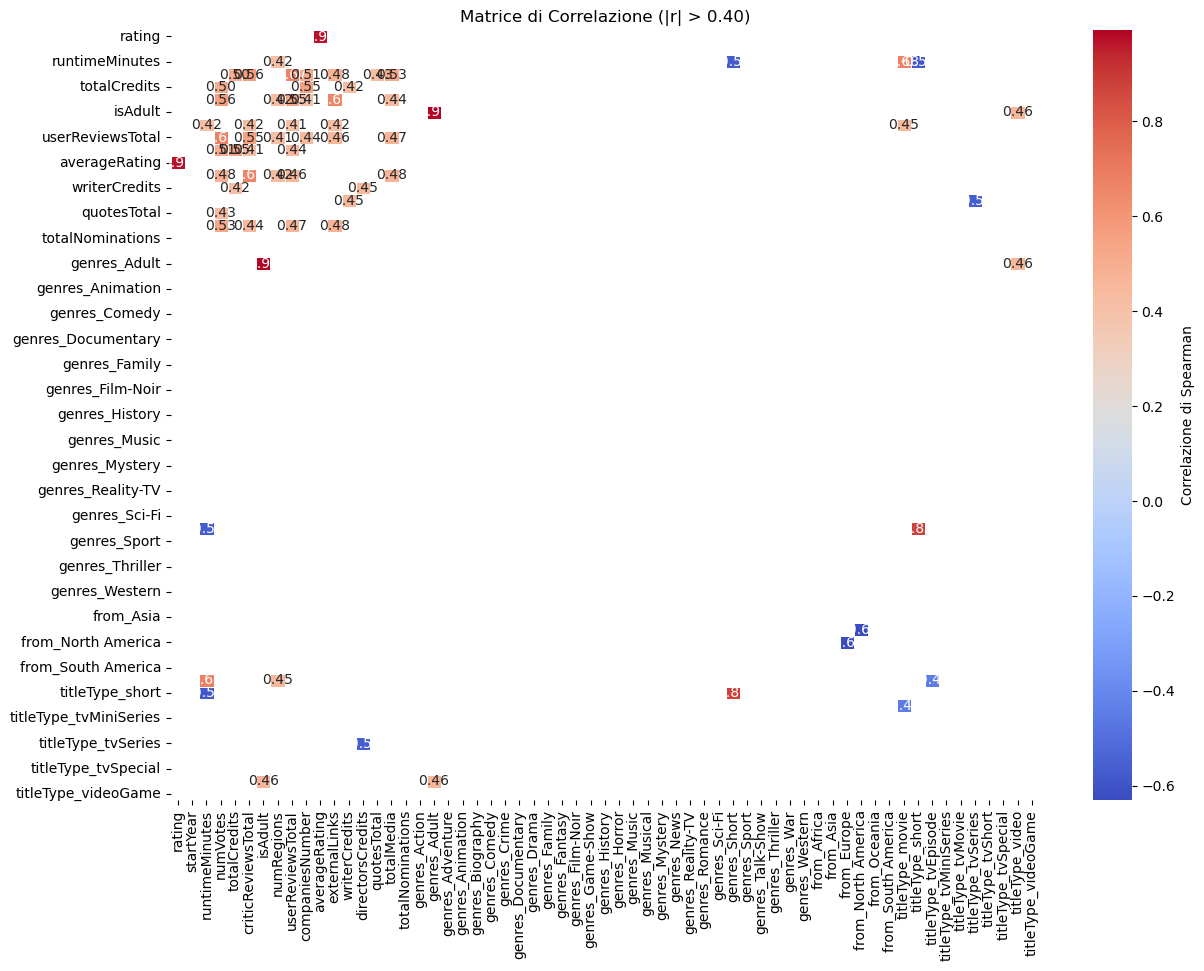


Coppie di variabili con correlazione > 0.40:
--------------------------------------------------
isAdult - genres_Adult: 0.992
rating - averageRating: 0.973
genres_Short - titleType_short: 0.876
runtimeMinutes - titleType_movie: 0.676
numVotes - userReviewsTotal: 0.670
criticReviewsTotal - externalLinks: 0.661
from_Europe - from_North America: -0.631
runtimeMinutes - titleType_short: -0.581
runtimeMinutes - genres_Short: -0.568
numVotes - criticReviewsTotal: 0.564
directorsCredits - titleType_tvSeries: -0.562
criticReviewsTotal - userReviewsTotal: 0.548
totalCredits - companiesNumber: 0.547
numVotes - totalMedia: 0.526
numVotes - companiesNumber: 0.511
numVotes - totalCredits: 0.503
numVotes - externalLinks: 0.480
externalLinks - totalMedia: 0.476
userReviewsTotal - totalMedia: 0.468
genres_Adult - titleType_video: 0.462
isAdult - titleType_video: 0.461
userReviewsTotal - externalLinks: 0.458
titleType_movie - titleType_tvEpisode: -0.452
numRegions - titleType_movie: 0.450
writerCredit

In [431]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Calcola la matrice di correlazione
correlation_matrix = df_encoded.corr(method='spearman', numeric_only=True)

# Crea una maschera per mostrare solo correlazioni > 0.40 (in valore assoluto)
# Escludiamo la diagonale principale (correlazione = 1)
mask = (np.abs(correlation_matrix) <= 0.40) | (correlation_matrix == 1.0)

# Crea una copia della matrice e imposta a NaN i valori che vogliamo nascondere
correlation_filtered = correlation_matrix.copy()
correlation_filtered[mask] = np.nan

# Crea il grafico
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_filtered, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={'label': 'Correlazione di Spearman'})
plt.title('Matrice di Correlazione (|r| > 0.40)')
plt.show()

# Opzionale: stampa le coppie di variabili con correlazione > 0.40
print("\nCoppie di variabili con correlazione > 0.40:")
print("-" * 50)

# Trova le correlazioni significative
high_corr = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.40:
            var1 = correlation_matrix.columns[i]
            var2 = correlation_matrix.columns[j]
            high_corr.append((var1, var2, corr_val))

# Ordina per valore di correlazione decrescente
high_corr.sort(key=lambda x: abs(x[2]), reverse=True)

for var1, var2, corr in high_corr:
    print(f"{var1} - {var2}: {corr:.3f}")

#### mutual information

In [432]:
from sklearn.metrics import mutual_info_score
import pandas as pd
 
X = df_encoded[['genres_Action', 'genres_Adult', 'genres_Adventure', 'genres_Animation', 'genres_Biography',
    'genres_Comedy', 'genres_Crime', 'genres_Documentary', 'genres_Drama', 'genres_Family',
    'genres_Fantasy', 'genres_Film-Noir', 'genres_Game-Show', 'genres_History', 'genres_Horror',
    'genres_Music', 'genres_Musical', 'genres_Mystery', 'genres_News', 'genres_Reality-TV',
    'genres_Romance', 'genres_Sci-Fi', 'genres_Short', 'genres_Sport', 'genres_Talk-Show',
    'genres_Thriller', 'genres_War', 'genres_Western', 'titleType_movie', 'titleType_short',
    'titleType_tvEpisode', 'titleType_tvMiniSeries', 'titleType_tvMovie', 'titleType_tvSeries',
    'titleType_tvShort', 'titleType_tvSpecial', 'titleType_video', 'titleType_videoGame']]
y = df_encoded[["from_Africa","from_Asia","from_Europe","from_North America","from_Oceania","from_South America"]]
 
results = {}
for target_col in y.columns:
    for feature_col in X.columns:
        mi = mutual_info_score(X[feature_col], y[target_col])
        results[(feature_col, target_col)] = mi
 
# Ordina per punteggi più alti
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
sorted_results

[(('genres_Action', 'from_Asia'), 0.02262705282241595),
 (('titleType_movie', 'from_Asia'), 0.015584626426638909),
 (('titleType_movie', 'from_North America'), 0.015286016084379489),
 (('genres_Action', 'from_Europe'), 0.014824478903196575),
 (('titleType_tvEpisode', 'from_North America'), 0.013727585895150884),
 (('genres_Animation', 'from_Asia'), 0.010144980096117112),
 (('titleType_tvEpisode', 'from_Europe'), 0.008305552242480807),
 (('titleType_short', 'from_Asia'), 0.007712654399708495),
 (('genres_Short', 'from_Asia'), 0.007266939788251971),
 (('genres_Western', 'from_North America'), 0.0072239831366581325),
 (('titleType_video', 'from_North America'), 0.0070028352858780285),
 (('genres_Documentary', 'from_Asia'), 0.006103707199221466),
 (('genres_Drama', 'from_North America'), 0.00556668031592461),
 (('genres_Adventure', 'from_Asia'), 0.005126705759068831),
 (('genres_Adult', 'from_North America'), 0.005121952787680562),
 (('titleType_tvMovie', 'from_Europe'), 0.0050648532670543

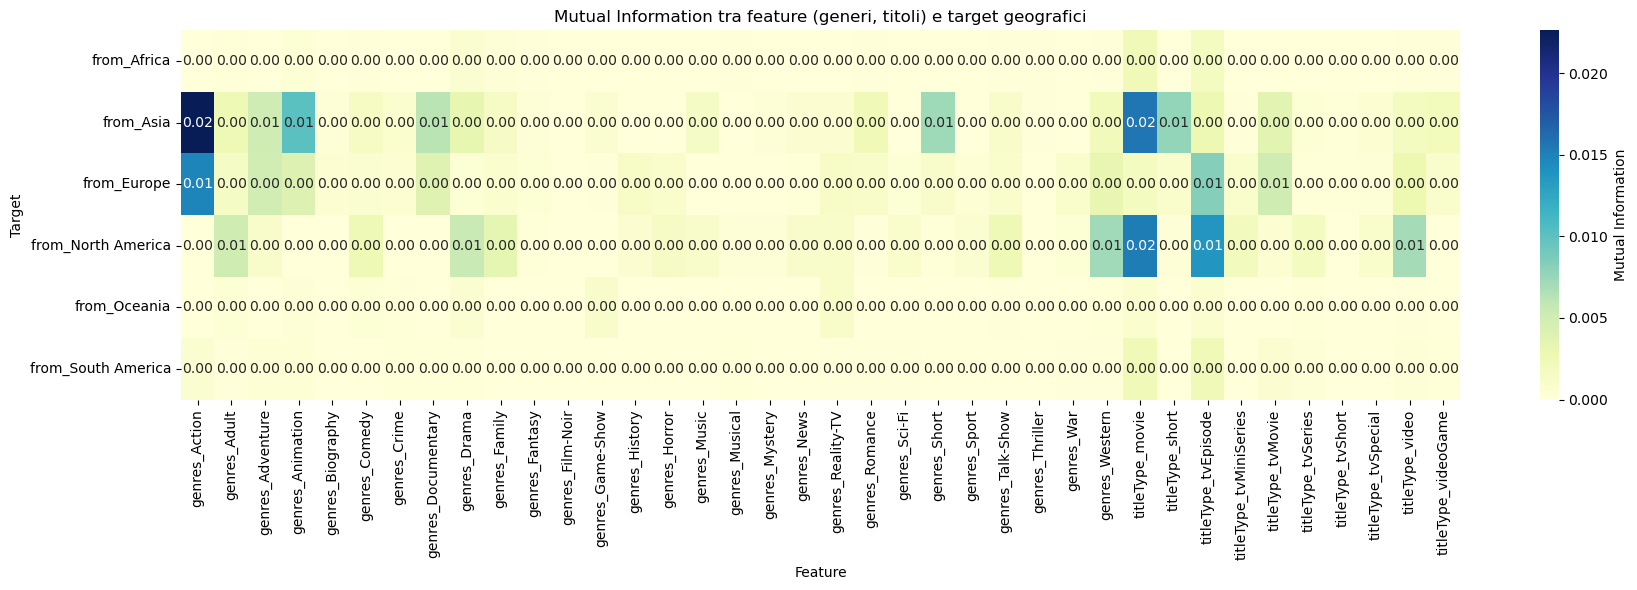

In [433]:
import pandas as pd
from sklearn.feature_selection import mutual_info_classif
import seaborn as sns
import matplotlib.pyplot as plt
 
# Indipendenti
X = df_encoded[[
    'genres_Action', 'genres_Adult', 'genres_Adventure', 'genres_Animation', 'genres_Biography',
    'genres_Comedy', 'genres_Crime', 'genres_Documentary', 'genres_Drama', 'genres_Family',
    'genres_Fantasy', 'genres_Film-Noir', 'genres_Game-Show', 'genres_History', 'genres_Horror',
    'genres_Music', 'genres_Musical', 'genres_Mystery', 'genres_News', 'genres_Reality-TV',
    'genres_Romance', 'genres_Sci-Fi', 'genres_Short', 'genres_Sport', 'genres_Talk-Show',
    'genres_Thriller', 'genres_War', 'genres_Western', 'titleType_movie', 'titleType_short',
    'titleType_tvEpisode', 'titleType_tvMiniSeries', 'titleType_tvMovie', 'titleType_tvSeries',
    'titleType_tvShort', 'titleType_tvSpecial', 'titleType_video', 'titleType_videoGame'
]]
 
# Target: colonne binarie per continente
target_columns = [
    "from_Africa", "from_Asia", "from_Europe", "from_North America",
    "from_Oceania", "from_South America"
]
 
# Calcolo della mutual information per ogni target
mi_df = pd.DataFrame(index=X.columns)
 
for target_col in target_columns:
    y = df_encoded[target_col]
    mi_scores = mutual_info_classif(X, y, discrete_features=True, random_state=0)
    mi_df[target_col] = mi_scores
 
# Trasposizione per facilitare la lettura (facoltativa)
mi_df = mi_df.T  # righe: target, colonne: feature
 
# Plot della heatmap
plt.figure(figsize=(18, 6))
sns.heatmap(mi_df, annot=True, fmt=".2f", cmap="YlGnBu", cbar_kws={'label': 'Mutual Information'})
plt.title("Mutual Information tra feature (generi, titoli) e target geografici")
plt.ylabel("Target")
plt.xlabel("Feature")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### lo stesso ma per adult ecc.

In [434]:
from sklearn.metrics import mutual_info_score
import pandas as pd
 
X = df_encoded[['genres_Adult']]
y = df_encoded[["isAdult"]]
 
results = {}
for target_col in y.columns:
    for feature_col in X.columns:
        mi = mutual_info_score(X[feature_col], y[target_col])
        results[(feature_col, target_col)] = mi
 
# Ordina per punteggi più alti
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
sorted_results

[(('genres_Adult', 'isAdult'), 0.11245288185786492)]

In [435]:
from sklearn.metrics import mutual_info_score
import pandas as pd
 
X = df_encoded[['titleType_short']]
y = df_encoded[["genres_Short"]]
 
results = {}
for target_col in y.columns:
    for feature_col in X.columns:
        mi = mutual_info_score(X[feature_col], y[target_col])
        results[(feature_col, target_col)] = mi
 
# Ordina per punteggi più alti
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
sorted_results

[(('titleType_short', 'genres_Short'), 0.2958852978466105)]

#### chi^2

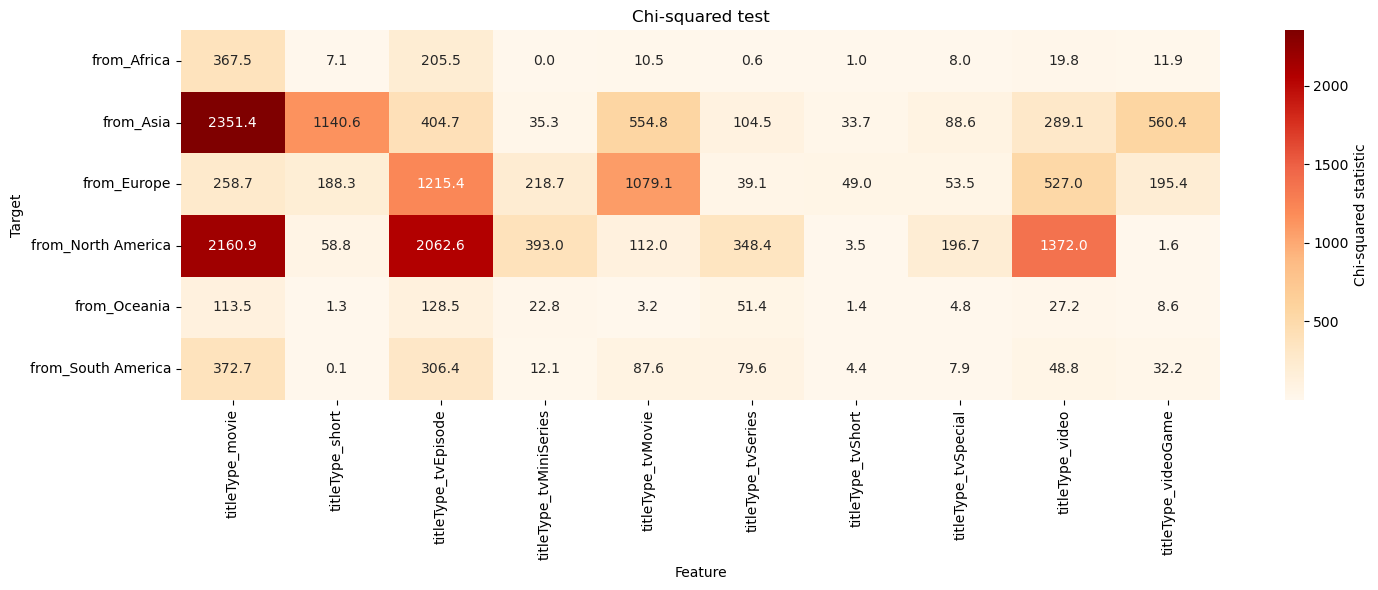

In [436]:
import pandas as pd
from sklearn.feature_selection import chi2
import seaborn as sns
import matplotlib.pyplot as plt
 
# Variabili indipendenti binarie (one-hot)
X = df_encoded[[
# "isAdult",
#     'genres_Action', 'genres_Adult', 'genres_Adventure', 'genres_Animation', 'genres_Biography',
#     'genres_Comedy', 'genres_Crime', 'genres_Documentary', 'genres_Drama', 'genres_Family',
#     'genres_Fantasy', 'genres_Film-Noir', 'genres_Game-Show', 'genres_History', 'genres_Horror',
#     'genres_Music', 'genres_Musical', 'genres_Mystery', 'genres_News', 'genres_Reality-TV',
#     'genres_Romance', 'genres_Sci-Fi', 'genres_Short', 'genres_Sport', 'genres_Talk-Show',
#     'genres_Thriller', 'genres_War', 'genres_Western', 
'titleType_movie', 'titleType_short',
    'titleType_tvEpisode', 'titleType_tvMiniSeries', 'titleType_tvMovie', 'titleType_tvSeries',
    'titleType_tvShort', 'titleType_tvSpecial', 'titleType_video', 'titleType_videoGame'
]]
 
# Target binari (uno per continente)
target_columns = [
    "from_Africa", "from_Asia", "from_Europe", "from_North America",
    "from_Oceania", "from_South America"
]
 
# Dizionario per salvare i risultati
chi2_results = pd.DataFrame(index=X.columns)
 
# Calcolo chi2 e p-value per ogni target
for target in target_columns:
    y = df_encoded[target]
    chi2_vals, p_vals = chi2(X, y)
    chi2_results[f'{target}_chi2'] = chi2_vals
    chi2_results[f'{target}_pval'] = p_vals
 
# Estrai solo le statistiche chi2 per visualizzazione
chi2_matrix = chi2_results.filter(like='_chi2')
chi2_matrix.columns = [col.replace('_chi2', '') for col in chi2_matrix.columns]
chi2_matrix = chi2_matrix.T  # righe = target, colonne = feature
 
# Heatmap dei valori chi2
plt.figure(figsize=(15, 6))
sns.heatmap(chi2_matrix, cmap='OrRd', annot=True, fmt=".1f", cbar_kws={'label': 'Chi-squared statistic'})
plt.title("Chi-squared test")
plt.ylabel("Target")
plt.xlabel("Feature")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### gestione isAdult/genres_Adult

In [437]:
df_encoded["genres_Adult"] = (df_encoded["isAdult"] == 1).astype(int)
df_encoded_nan["genres_Adult"] = (df_encoded_nan["isAdult"] == 1).astype(int)

In [438]:
df_encoded.drop("isAdult", axis=1, inplace=True)
df_encoded_nan.drop("isAdult", axis=1, inplace=True)

### creazione base per classificazione countryoforigin

In [439]:
conts = [
    "from_Africa", "from_Asia", "from_Europe", "from_North America",
    "from_Oceania", "from_South America"
]
for c in conts:
    df_encoded_nan[c] = np.nan

In [440]:
df_encoded_nan

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,countryOfOrigin,...,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame,from_Africa,from_Asia,from_Europe,from_North America,from_Oceania,from_South America
0,'Round the World in 80 Days,5,1914,NaN,41,2,0,2,1,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
1,The Greatest Man in the World,8,1958,57.0,26,32,0,0,4,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
2,A Free Agent,7,1964,60.0,12,35,0,0,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
3,A Guide to Armageddon,9,1982,NaN,76,9,0,0,4,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,A félelem ára,6,1993,60.0,6,94,0,0,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39456,Women Take Center Stage,6,2019,NaN,12,32,0,0,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
39457,Horrid Henry and the Christening Crisis,7,2011,10.0,9,15,0,0,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
39458,A lenda do soprador de vidro,9,2019,NaN,9,33,0,0,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
39459,Chi Nhung,7,1970,66.0,15,11,0,8,0,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [441]:
df_encoded_nan.drop("countryOfOrigin", axis=1, inplace=True)

### confronto finale

In [442]:
# Supponiamo che i tuoi DataFrame si chiamino df1 e df2

# Trova le colonne che sono in df1 ma non in df2
diff1 = set(df_encoded.columns) - set(df_encoded_nan.columns)

# Trova le colonne che sono in df2 ma non in df1
# diff2 = set(df2.columns) - set(df1.columns)

# Mostra il risultato
print("Colonne presenti solo in df1:", diff1)
#print("Colonne presenti solo in df2:", diff2)


Colonne presenti solo in df1: {'genres_Film-Noir'}


In [443]:
# df_encoded.drop("genres_Film-Noir", axis=1, inplace=True)

In [444]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 106716 entries, 0 to 106870
Data columns (total 61 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   originalTitle           106716 non-null  object 
 1   rating                  106716 non-null  int32  
 2   startYear               106716 non-null  int64  
 3   runtimeMinutes          87872 non-null   float64
 4   numVotes                106716 non-null  int64  
 5   totalCredits            106716 non-null  int64  
 6   criticReviewsTotal      106716 non-null  int64  
 7   numRegions              106716 non-null  int64  
 8   userReviewsTotal        106716 non-null  int64  
 9   companiesNumber         106716 non-null  int64  
 10  averageRating           106716 non-null  float64
 11  externalLinks           106716 non-null  int64  
 12  writerCredits           106716 non-null  int64  
 13  directorsCredits        106716 non-null  int64  
 14  quotesTotal             1

In [445]:
df_encoded_nan.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 39461 entries, 0 to 39460
Data columns (total 60 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   originalTitle           39461 non-null  object 
 1   rating                  39461 non-null  int32  
 2   startYear               39461 non-null  int64  
 3   runtimeMinutes          19800 non-null  float64
 4   numVotes                39461 non-null  int64  
 5   totalCredits            39461 non-null  int64  
 6   criticReviewsTotal      39461 non-null  int64  
 7   numRegions              39461 non-null  int64  
 8   userReviewsTotal        39461 non-null  int64  
 9   companiesNumber         39461 non-null  int64  
 10  averageRating           39461 non-null  float64
 11  externalLinks           39461 non-null  int64  
 12  writerCredits           39461 non-null  int64  
 13  directorsCredits        39461 non-null  int64  
 14  quotesTotal             39461 non-null

### download df

In [446]:
df_encoded[df_encoded.duplicated(subset=[col for col in df_encoded.columns if col not in ['originalTitle']], keep=False)]

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,...,titleType_movie,titleType_short,titleType_tvEpisode,titleType_tvMiniSeries,titleType_tvMovie,titleType_tvSeries,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame
38047,Am Wasserfall,4,1897,NaN,14,1,0,1,0,1,...,0,1,0,0,0,0,0,0,0,0
43591,The Fear: Part 2,8,1988,NaN,9,66,0,1,0,2,...,0,0,1,0,0,0,0,0,0,0
45401,Home Sweet Home,9,1990,NaN,16,85,0,1,0,3,...,0,0,1,0,0,0,0,0,0,0
45410,My Love Always,9,1990,NaN,16,85,0,1,0,3,...,0,0,1,0,0,0,0,0,0,0
52454,Episode #39.5,7,1998,NaN,8,6,0,7,0,1,...,0,0,1,0,0,0,0,0,0,0
52456,Episode #39.8,7,1998,NaN,8,6,0,7,0,1,...,0,0,1,0,0,0,0,0,0,0
52957,Bed and Board,8,1988,NaN,9,66,0,1,0,2,...,0,0,1,0,0,0,0,0,0,0
53749,Passé compliqué,7,1994,30.0,7,12,0,1,0,5,...,0,0,1,0,0,0,0,0,0,0
54281,Essai non concluant,7,1994,30.0,7,12,0,1,0,5,...,0,0,1,0,0,0,0,0,0,0
55195,Episode #1.1006,7,1970,23.0,21,31,0,7,1,7,...,0,0,1,0,0,0,0,0,0,0


In [447]:
df_encoded_nan[df_encoded_nan.duplicated(subset=[col for col in df_encoded_nan.columns if col not in ['originalTitle']], keep=False)]

,originalTitle,rating,startYear,runtimeMinutes,numVotes,totalCredits,criticReviewsTotal,numRegions,userReviewsTotal,companiesNumber,...,titleType_tvShort,titleType_tvSpecial,titleType_video,titleType_videoGame,from_Africa,from_Asia,from_Europe,from_North America,from_Oceania,from_South America
6214,Paper Trail,6,1998,NaN,15,57,0,0,0,2,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
6217,The Really Real Reenactment,6,1998,NaN,15,57,0,0,0,2,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
10460,Rare Earth Elements/Jerry and Marge Selbee/Sam...,7,2019,43.0,7,21,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
10921,High Velocity/This is No Ordinary Lawsuit/Paul...,7,2019,43.0,7,21,0,0,0,0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
11171,The Crucifixion of Jesus,8,2016,NaN,5,18,0,0,0,2,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
11172,The Resurrection of Jesus,8,2016,NaN,5,18,0,0,0,2,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
11215,Grand Championship Final: DePaoli vs.Miller/Wi...,7,1993,NaN,9,23,0,0,0,1,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
11653,Second Half Preliminary Round 3: Cruz vs. Shri...,7,1993,NaN,9,23,0,0,0,1,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
19869,Jeffrey Finds a Friend,8,1985,NaN,12,38,0,0,0,4,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
19874,Griff Makes a Date,8,1985,NaN,12,38,0,0,0,4,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN


In [448]:
df_encoded.to_csv("df_encoded.csv", index=False)
df_encoded_nan.to_csv("df_encoded_nan.csv", index=False)